In [15]:
import pandas as pd
import sqlite3
conn= sqlite3.connect('real_waste_project.db')

In [16]:
waste_df=pd.read_csv('municipal-waste-recycling-rate.csv')
countries_df=pd.read_csv('world-bank-income-groups.csv')
recycling_df=pd.read_csv('electronic-waste-recycling-rate.csv')
income_df=pd.read_csv('world-bank-income-groups.csv')


In [17]:
countries_df.to_sql('countries',conn ,if_exists='replace',index=False)
waste_df.to_sql('waste_production',conn ,if_exists='replace',index=False)
recycling_df.to_sql('recycling_rate',conn ,if_exists='replace',index=False)
income_df.to_sql('income_groups',conn ,if_exists='replace',index=False)




7953

In [18]:
df= pd.read_sql("SELECT* FROM waste_production LIMIT 5", conn)
print(df)

      Entity Code  Year  Variable:% Recycling - MUNW
0  Australia  AUS  2003                       30.338
1  Australia  AUS  2009                       40.976
2  Australia  AUS  2011                       45.173
3  Australia  AUS  2015                       41.585
4    Austria  AUT  1990                       11.358


In [29]:
query01=pd.read_sql("""SELECT Entity, AVG("Variable:% Recycling - MUNW") as avg_recycling 
FROM waste_production
GROUP BY Entity
ORDER BY avg_recycling DESC
LIMIT 10
""",conn)
print("Top 10 Recycling Countries:")
print(query01)

Top 10 Recycling Countries:
        Entity  avg_recycling
0      Germany      40.466727
1    Australia      39.518000
2        Korea      38.635739
3  Switzerland      31.214192
4       Sweden      29.887217
5      Finland      24.541864
6      Belgium      24.290654
7      Denmark      24.027304
8      Austria      23.862308
9   Luxembourg      23.676762


In [32]:
query02=pd.read_sql("""SELECT Entity, Year, AVG("Variable:% Recycling - MUNW") as avg_recycling
FROM waste_production
GROUP BY Entity
ORDER BY Year
LIMIT 15
""", conn)
print("Recycling Rate Over Time:")
print(query02)

Recycling Rate Over Time:
           Entity  Year  avg_recycling
0         Austria  1990      23.862308
1         Belgium  1990      24.290654
2          Greece  1990      10.571900
3         Hungary  1990       9.029565
4           Japan  1990      14.782040
5           Korea  1990      38.635739
6          Sweden  1990      29.887217
7     Switzerland  1990      31.214192
8   United States  1990      22.162720
9          Mexico  1991       2.866136
10    Netherlands  1991      22.490583
11         Norway  1992      22.807208
12        Denmark  1993      24.027304
13         France  1993      15.480636
14        Germany  1993      40.466727


In [40]:
query03=pd.read_sql("""SELECT Entity, Year, "Variable:% Recycling - MUNW" as recycling_rate
FROM waste_production
WHERE "Variable:% Recycling - MUNW" > 40
ORDER BY recycling_rate DESC
""", conn)
print("Countries above 40% recycling:")
print(query03)

Countries above 40% recycling:
       Entity  Year  recycling_rate
0       Korea  2010          59.929
1       Korea  2009          59.803
2       Korea  2013          58.653
3       Korea  2008          58.382
4       Korea  2012          58.364
5       Korea  2011          58.295
6       Korea  2014          58.104
7       Korea  2005          56.289
8       Korea  2004          49.170
9     Germany  2015          47.827
10   Slovenia  2015          47.796
11    Germany  2014          47.556
12    Germany  2012          47.421
13    Germany  2007          47.100
14    Germany  2008          47.040
15    Germany  2013          46.584
16    Germany  2011          46.052
17    Germany  2009          45.814
18    Germany  2006          45.653
19    Germany  2010          45.650
20      Korea  2003          45.211
21  Australia  2011          45.173
22    Germany  2005          44.537
23      Korea  2002          43.983
24    Germany  2003          43.176
25      Korea  2001          43.1

/tmp/ipykernel_705/3576262717.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Entity", y="avg_recycling", palette="Blues")


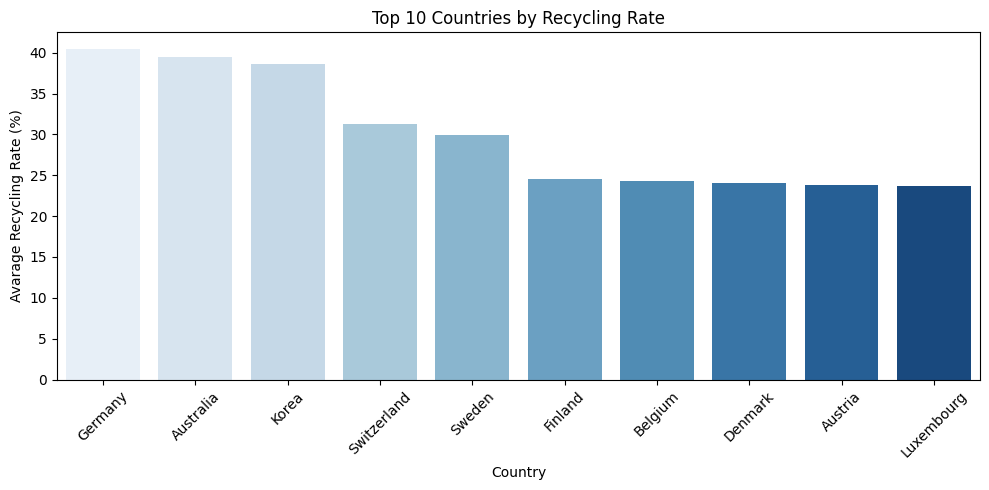

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = pd.read_sql("""SELECT Entity, AVG("Variable:% Recycling - MUNW") as avg_recycling
FROM waste_production
GROUP BY Entity 
ORDER BY avg_recycling DESC
LIMIT 10
""", conn)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="Entity", y="avg_recycling", palette="Blues")
plt.title("Top 10 Countries by Recycling Rate")
plt.xlabel("Country")
plt.ylabel("Avarage Recycling Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
            

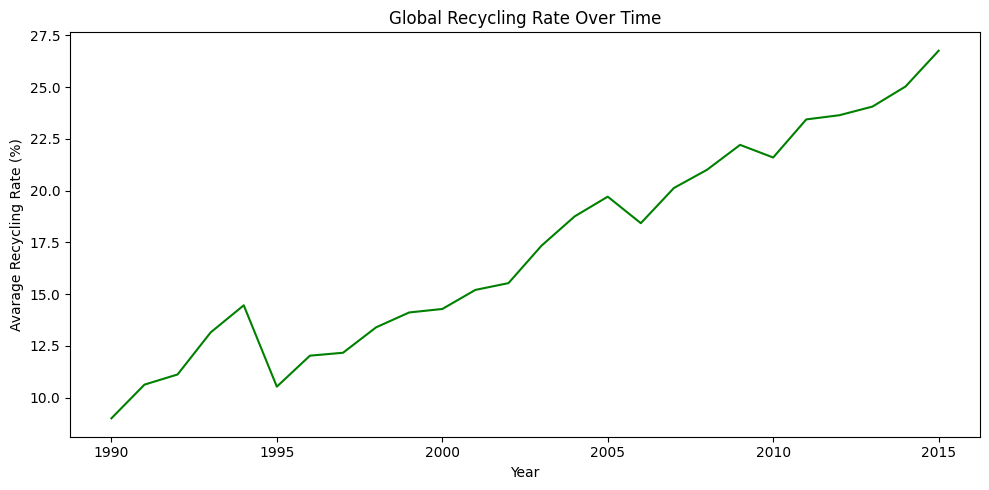

In [54]:
overtime = pd.read_sql("""SELECT Year, AVG("Variable:% Recycling - MUNW") as avg_recycling
FROM waste_production
GROUP BY Year
ORDER BY Year
""", conn)

plt.figure(figsize=(10,5))
sns.lineplot(data=overtime, x="Year", y="avg_recycling", color="green")
plt.title("Global Recycling Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Avarage Recycling Rate (%)")
plt.tight_layout()
plt.show()

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

ml_data = pd.read_sql("""SELECT Year, AVG("Variable:% Recycling - MUNW") as avg_recycling 
FROM waste_production
GROUP BY Year
ORDER BY Year
""", conn)

ml_data = ml_data.dropna()

print(ml_data.columns.tolist())
print(ml_data.head())

X = ml_data[["Year"]]
Y = ml_data["avg_recycling"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, Y_train)

score = model.score(X_test, Y_test)
print(f"Model accuracy: {score:.2f}")
print(f"prediction for 2028:{model.predict([[2025]])[0]:.2f}%")

['Year', 'avg_recycling']
   Year  avg_recycling
0  1990       9.005000
1  1991      10.633125
2  1992      11.123111
3  1993      13.153667
4  1994      14.462071
Model accuracy: 0.89
prediction for 2028:31.65%


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


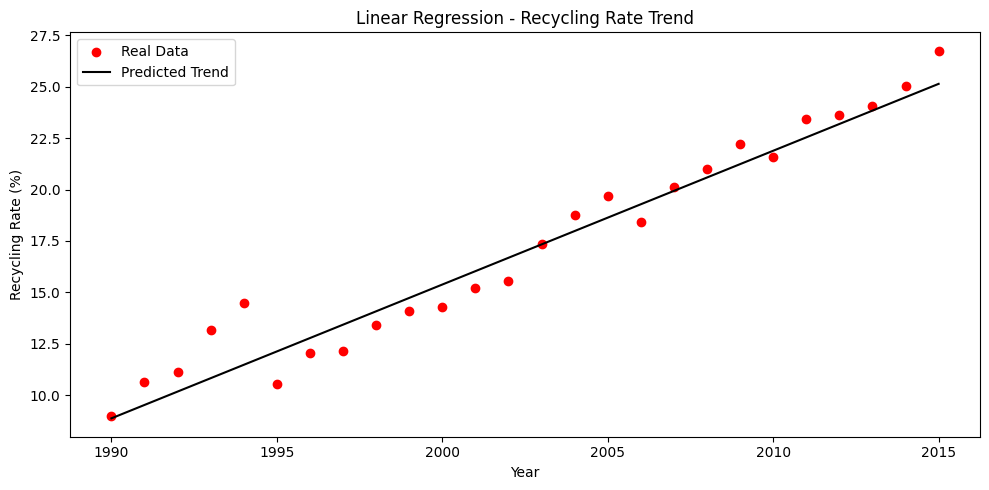

In [70]:
plt.figure(figsize=(10,5))
plt.scatter(X, Y, color="red", label="Real Data")
plt.plot(X, model.predict(X), color="black", label="Predicted Trend")
plt.title("Linear Regression - Recycling Rate Trend")
plt.xlabel("Year")
plt.ylabel("Recycling Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()